In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn

reinforce w/ baseline

In [4]:
class ValueFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)

        return x


class PolicyFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, 1)
        self.sig2 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)
        x = self.sig2(x)

        return x

In [ ]:
#init theta in R^d', init w in R^d
INPUT_DIM = 6
LAYER2_DIM = 10
EPISODES = 25000

def state_to_idx(s): return s[0]-1, s[1]-1, s[2]
def x(s1, s2, s3):
    ps, ds = s1 / 20.0, s2 / 9.0
    return np.array([1.0, ps, ds, float(s3), ps * ds, ps * s3])


env = gym.make("Blackjack-v1", sab=False)


model_v = ValueFcnApprox(INPUT_DIM, LAYER2_DIM)
model_p = PolicyFcnApprox(INPUT_DIM, LAYER2_DIM)


wins = []

#for episode in episodes:
for episode in range(EPISODES):
    #generate episode
    s, _ = env.reset()
    s_ls, a_ls, r_ls, logpi_ls = [], [], [], []

    while True:
        s1, s2, s3 = state_to_idx(s)
        xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)

        p_hit = model_p(xi).squeeze()
        # a = torch.bernoulli(p_hit).long().item()
        # log_pi = torch.log(p_hit if a == 1 else (1 - p_hit))
        dist = torch.distributions.Bernoulli(probs=p_hit)
        a = dist.sample()
        log_pi = dist.log_prob(a)

        s_ls.append(xi)
        a_ls.append(a.item())
        logpi_ls.append(log_pi)

        s, r, term, trunc, _ = env.step(a)
        r_ls.append(r)

        if term or trunc:
            wins.append(r > 0)
            break

 
    #for t in episode:
        #calculate return g, g <- sum from k=t+1 to T gamma^k-1 R_k
        #calculate target minus estimate delta, delta <- g - v(s_t, w)
        #update weight vector for w, w <- w + alpha * delta del v(s_t, w)
        #update policy param theta, theta <- theta + alpha * gamma^t * delta * del ln(pi(a|s, theta))

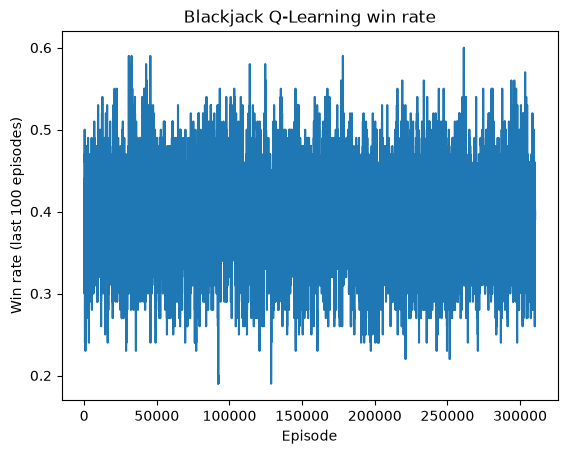

In [ ]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack Reinforce w/ Baseline win rate')
plt.show()

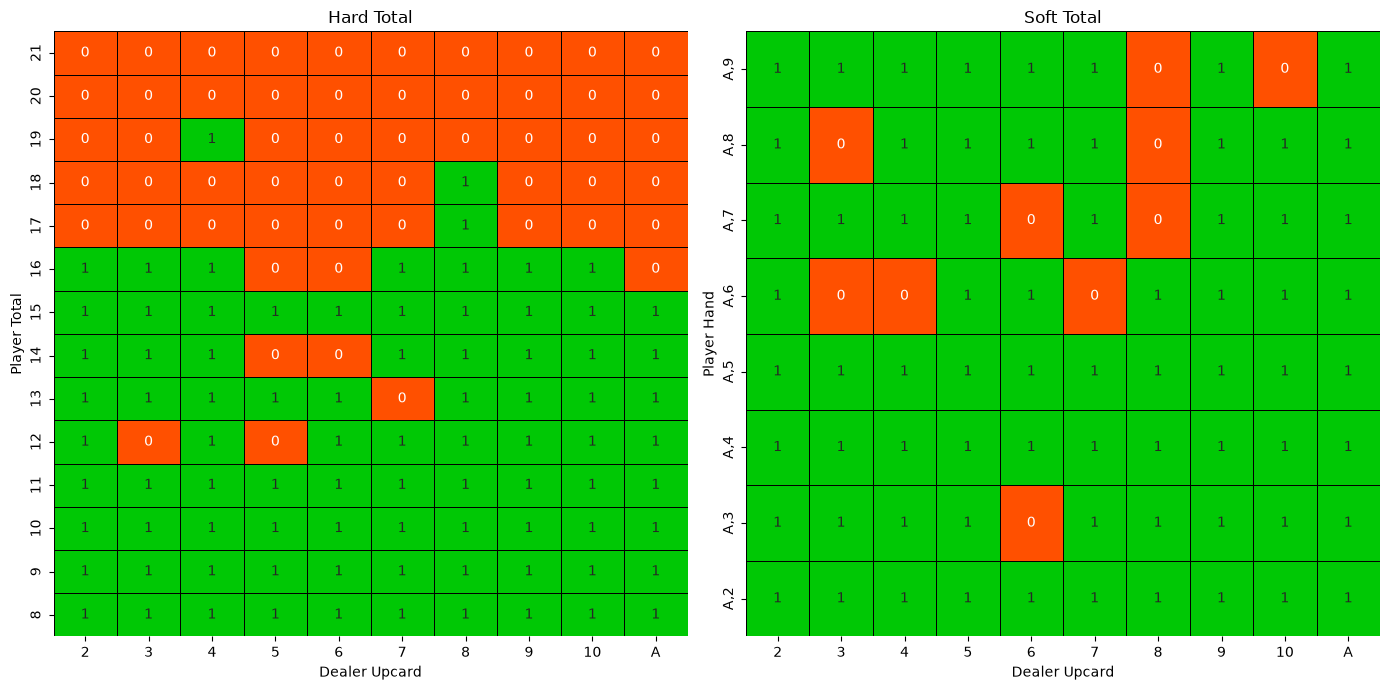

In [ ]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 0]),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 1]),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()